
# **<font color='purple'> `Part 6: Early Detection of potential new variants`</font>**
***
**Student**


|         Full name         |   Username  |         Email         |
|---------------------------|-------------|-----------------------|
| Emmanuel Nyandu Kagarabi  | emmanuelnk  | emmanuelnk@aims.ac.za |

<font color='teal'>`AI-Powered Classification and Early Detection of Dengue Lineages for a Timely Public Health Response`</font>

<table align="left">
  <td>
    <a href="https://colab.research.google.com/drive/1wFFV4kAQYIcsx3T72NE7O8jTBqDpGad9?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>

In [ ]:
# @title Zip and Download the Entire Content of the Current Virtual Machine Before Its Expiration
# 1. Zip
#!zip -r FULL_DATA_VM_EMMA_CERI_DENGUE_PROJECT.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2024.09.20/ (stored 0%)
  adding: content/.config/logs/2024.09.20/13.21.34.104159.log (deflated 58%)
  adding: content/.config/logs/2024.09.20/13.21.56.905204.log (deflated 56%)
  adding: content/.config/logs/2024.09.20/13.21.44.777817.log (deflated 85%)
  adding: content/.config/logs/2024.09.20/13.21.56.246468.log (deflated 57%)
  adding: content/.config/logs/2024.09.20/13.21.13.139283.log (deflated 93%)
  adding: content/.config/logs/2024.09.20/13.21.45.853413.log (deflated 58%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 23%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: co

In [ ]:
#2. Download
#from google.colab import files
#files.download('FULL_DATA_VM_EMMA_CERI_DENGUE_PROJECT.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# `1. Imports`

In [1]:
#@title Installations
!pip install Bio
!pip install prince
!pip install imbalanced-learn
!pip install pandas biopython
!pip install scikit-learn
!pip install xgboost
!pip install hiclass
!pip install mmh3
!pip install keras-self-attention
# Clean installation outputs`
from IPython.display import clear_output
clear_output()

In [2]:
#@title Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input, Conv1D,Conv2D,MaxPooling1D,MaxPooling2D, Flatten,BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.preprocessing.sequence import pad_sequences
import requests
from Bio import SeqIO, Phylo
import prince
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
from collections import defaultdict
import re
import os
import zipfile
from sklearn import tree
from scipy.fftpack import fft
import mmh3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, roc_curve, auc, classification_report)
from xgboost import XGBClassifier
import lightgbm as lgb
from hiclass import (LocalClassifierPerNode, LocalClassifierPerParentNode, LocalClassifierPerLevel)
#from sklearn.utils.multiclass import unique_label
from scipy.stats import entropy
from scipy.sparse import issparse
from datetime import datetime
from random import shuffle
import json
import joblib
%matplotlib inline
import time
from keras_self_attention import SeqSelfAttention #Import the SeqSelfAttention layer
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Random Sampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from itertools import cycle
now = datetime.now()
now.strftime("%H:%M:%S")

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


'12:05:51'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#@title Unzip the saved models
# def unzip_folder(zip_path, extract_path='/content'):
#     """
#     Unzip a folder and save the contents to the specified path, maintaining the folder hierarchy.

#     Args:
#     zip_path (str): Path to the zip file
#     extract_path (str): Path where the contents will be extracted (default: '/content')

#     Returns:
#     bool: True if successful, False otherwise
#     """
#     try:
#         # Ensure the zip file exists
#         if not os.path.exists(zip_path):
#             print(f"Error: The file {zip_path} does not exist.")
#             return False

#         # Create the extraction directory if it doesn't exist
#         os.makedirs(extract_path, exist_ok=True)

#         # Open the zip file
#         with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#             # Extract all contents to the specified path
#             zip_ref.extractall(extract_path)

#             # Get the list of all files and folders in the zip
#             file_list = zip_ref.namelist()

#             # Find the root folder name (if any)
#             root_folder = file_list[0].split('/')[0] if '/' in file_list[0] else ''

#             print(f"Successfully unzipped {zip_path} to {extract_path}")
#             print(f"Root folder name: {root_folder}")
#             print("Folder structure:")

#             # Print the folder structure
#             for item in file_list:
#                 print(f"  {item}")

#         return True

#     except zipfile.BadZipFile:
#         print(f"Error: {zip_path} is not a valid zip file.")
#         return False
#     except Exception as e:
#         print(f"An error occurred: {str(e)}")
#         return False

In [7]:
# @title Unzipping...
# result = unzip_folder('/content/drive/MyDrive/AIMS_COURSES/AIMS_CERI_PROJECT/MY_CODE_FROM_SCRATCH/0ctober_24_2024_Submission/FULL_DATA_VM_EMMA_CERI_DENGUE_PROJECT.zip')

# if result:
#     print("Unzipping completed successfully.")
# else:
#     print("Unzipping failed.")

# `2. DATASETS`

# `2.1. Minor Lineages`

In [11]:
df_minor_lineages = pd.read_csv('/content/content/FINAL_DATASET/DEADLINE_RESULTS/minor_lineages.csv')
df_minor_lineages.head()

,Minor Lineage,Most Common Region,Oldest Date
0,1I_E.1,Southeast Asia,2015-01-01
1,1I_E.2,Pacific,2016-02-01
2,1I_H.1,Southeast Asia,2006-01-01
3,1I_H.2,Southeast Asia,2006-01-01
4,1I_K.1,East Asia,2014-01-01


# `2.2. Genomic sequences`

In [12]:
df = pd.read_csv('/content/content/VM_4_COLAB_DATA/df_final_dengue_dataset.csv')

In [13]:
# Cheking:
df.head()

,Sequence,Length,Serotype,Lineage,Lineage_Label,Taxonomic_Lineage,Hierarchy,Collection date,Submission date,Location
0,TAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGCTTGCT...,10652,DENV1,1I_K.2,5,1_I_K_2,"['1', 'I', 'K', '2']",2022-05-24,2023-11-16,Asia / Indonesia / Bali
1,CGTGGACCGACAAAGACAGATTCTTTGAGGAAGCTAAGCTTAACGT...,10490,DENV2,2II_F.1.2,20,2_II_F_1.2,"['2', 'II', 'F', '1.2']",2024-03-22,2024-05-24,South America / Ecuador / Loja
2,CGACTCGGAAGCTTGCTTAACGTAGTGCTAACAGTTTTTATTAGAG...,10461,DENV3,3III_B.3,24,3_III_B_3,"['3', 'III', 'B', '3']",2023-06-08,2023-10-10,North America / USA / Florida
3,CACAGTTGGCGAAGAGATTCTCAAAAGGATTGCTGAACGGCCAGGG...,10393,DENV3,3III_C.2,26,3_III_C_2,"['3', 'III', 'C', '2']",2022-09-27,2023-05-20,North America / Mexico / Veracruz
4,TTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTTTATT...,10087,DENV1,1V_D.1,7,1_V_D_1,"['1', 'V', 'D', '1']",2020-12-18,2023-04-13,North America / USA / Florida


# `2.3. Synthetic data`

In [14]:
#@title 2.3.1. Convert the generated dataset to a dataframe
def fasta_to_dataframe(fasta_file):
    records = []
    for record in SeqIO.parse(fasta_file, 'fasta'):
        records.append({
            'ID': record.description,
            'Sequence': str(record.seq)
        })
    df = pd.DataFrame(records)
    return df
# Read in the generated dataframe
generated_fasta_path = "/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2024_10_11_FINAL_DENGUE_DETECTIVE_SEQUENCES.fasta"
generated_df = fasta_to_dataframe(generated_fasta_path)
generated_df.head()

,ID,Sequence
0,VAE_SAMPLE_1,ACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTT...
1,VAE_SAMPLE_2,AGTNGTTAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAG...
2,VAE_SAMPLE_6,GACAAGGACAGTTCCAAATCGGAAGCTTGCTTAACACAGTTCTAAC...
3,VAE_SAMPLE_9,TGTTAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGCTT...
4,VAE_SAMPLE_12,CGCCTTTCAATATGCTGAAACGCGAGAGAAACCGCGTGTCGACTGT...


In [15]:
#@title 2.3.2 Clean the dataset
def clean_generated_data(df):
    # Remove ambiguous nucleotides
    valid_letters = ['A', 'C', 'G', 'T']
    df['Sequence'] = df['Sequence'].apply(lambda seq: ''.join([n for n in seq if n in valid_letters]))
    # Add a column which computes the sequence length
    df['Length'] = df['Sequence'].apply(lambda seq: len(seq))
    return df
# Clean our generated dataset
generated_df = clean_generated_data(generated_df)

In [16]:
#@title 2.3.3. Sequences Lengths Distribution
max_length = generated_df['Length'].max()
def plot_length_distribution(df,lenth=max_length):
    sns.histplot(df['Length'], kde=True, color='magenta', alpha=0.7)
    plt.axvline(lenth, color='blue', linestyle='--', linewidth=2,label=f'Maximum Length : {max_length} nucleotides')
    plt.legend()
    plt.title('Distribution of the Generated Sequence Lengths',fontsize=12,fontweight='bold')
    plt.xlabel('Length')
    plt.ylabel('Frequency')
    plt.grid(linestyle='--', alpha=0.5)
    plt.savefig('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/gen_Length_distribution.pdf', format='pdf')
    plt.show()

In [17]:
generated_df['Length'].describe().T

,Length
count,43.000000
mean,10415.465116
std,386.234838
min,8116.000000
25%,10369.500000
50%,10409.000000
75%,10585.500000
max,10706.000000


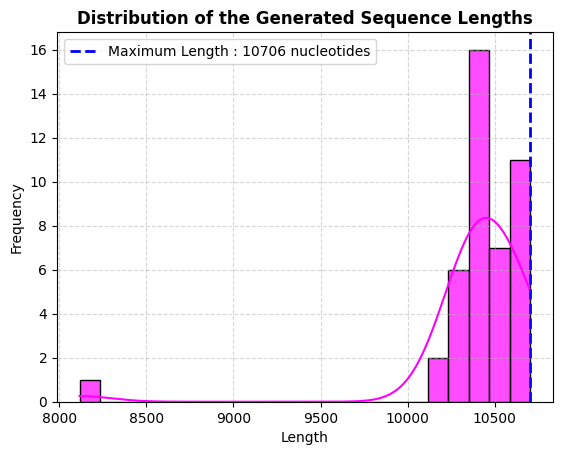

In [18]:
plot_length_distribution(generated_df)

In [19]:
#@title 2.3.4 Save the cleaned version
generated_df.to_csv('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/Deadline_Cleaned_Valid_VAE_Samples.csv', index=False)

In [20]:
#@title 2.3.5 Read the saved dataframe
generated_df = pd.read_csv('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/Deadline_Cleaned_Valid_VAE_Samples.csv')
generated_df.head()

,ID,Sequence,Length
0,VAE_SAMPLE_1,ACAGTTTCGAATCGGAAGCTTGCTTAACGTAGTTCTAACAGTTTTT...,10405
1,VAE_SAMPLE_2,AGTGTTAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGC...,10685
2,VAE_SAMPLE_6,GACAAGGACAGTTCCAAATCGGAAGCTTGCTTAACACAGTTCTAAC...,10547
3,VAE_SAMPLE_9,TGTTAGTCTACGTGGACCGACAAGAACAGTTTCGAATCGGAAGCTT...,10706
4,VAE_SAMPLE_12,CGCCTTTCAATATGCTGAAACGCGAGAGAAACCGCGTGTCGACTGT...,10409


In [21]:
generated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        43 non-null     object
 1   Sequence  43 non-null     object
 2   Length    43 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB


# `2.4. Genome Detective Typing Tool Results`

In [22]:
#@title 2.4.1. Read Results : Each unkown lineage is considered as "Uncertain"
def read_genome_detective_results(file_path):
    df1 = pd.read_csv(file_path)

    # Create a set of minor lineages for faster lookup
    minor_lineage_set = set(df_minor_lineages['Minor Lineage'])

    # Define a function to apply the replacement logic
    def replace_lineage(lineage):
        return lineage if lineage in minor_lineage_set else 'Uncertain'

    # Apply the function to the 'Lineage' column in df2
    df1['Lineage'] = df1['Lineage'].apply(replace_lineage)

    # Rename the Lineage column
    df1.rename(columns={'Lineage': 'Genome_Detective_Typing_Tool_Lineage'}, inplace=True)

    # Select only the columns ID and renammed Lineage
    df1 = df1[['ID', 'Genome_Detective_Typing_Tool_Lineage']]
    return df1

In [23]:
#@title 2.4.2. Convert the results to a dataframe
df1 = read_genome_detective_results('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2024_10_11_FINAL_DENGUE_DETECTIVE_RESULTS.csv')
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 2 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   ID                                    43 non-null     object
 1   Genome_Detective_Typing_Tool_Lineage  43 non-null     object
dtypes: object(2)
memory usage: 816.0+ bytes


In [24]:
# Save the current Results
df1.to_csv('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/2024_10_11_FINAL_DENGUE_DETECTIVE_RESULTS.csv', index=False)

In [25]:
# Quick read
df1 = pd.read_csv('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/2024_10_11_FINAL_DENGUE_DETECTIVE_RESULTS.csv')
df1.head()

,ID,Genome_Detective_Typing_Tool_Lineage
0,VAE_SAMPLE_1,1IV_B.1
1,VAE_SAMPLE_2,1IV_B.1
2,VAE_SAMPLE_6,4I_A.1.1
3,VAE_SAMPLE_9,1I_K.3
4,VAE_SAMPLE_12,2V_A.1


# `3. Early Detection`



# `3.1. Helpers`

In [26]:
#@title 3.1.1 Different formats : 5-mers (ML), 32-FCGR (ML), One-hot encoding (DL), and 32-FCGR (DL)
def preprocessing_for_pretrained_models(df_vae, df, resolution_=32,k_=5):

    #(1) Maximum length :
    max_length = df['Length'].max()

    # (2) Usefull functions:

    ##### 2.1. One-hot encoding
    def one_hot_encode(sequence, l_max = max_length):
        mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}
        encoded = [mapping.get(nucleotide, [0,0,0,0]) for nucleotide in sequence]
        padded = encoded + [[0,0,0,0]] * (l_max - len(encoded))
        return np.array(padded)

    ##### 2.2. FCGR (ML)
    def machine_learning_fcgr(sequence, resolution):
        grid = np.zeros((resolution, resolution))
        x, y = 0.5, 0.5
        for nucleotide in sequence:
            if nucleotide == 'A':
                x, y = x / 2, y / 2
            elif nucleotide == 'C':
                x, y = x / 2, (y + 1) / 2
            elif nucleotide == 'G':
                x, y = (x + 1) / 2, (y + 1) / 2
            elif nucleotide == 'T':
                x, y = (x + 1) / 2, y / 2
            grid[int(x * resolution), int(y * resolution)] += 1
        return grid.flatten()


    ##### 2.3. k-mers
    def get_kmers(sequence, k):
        return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

    ##### 2.4. FCGR (DL)
    def deep_learning_fcgr(sequence, resolution):
        grid = np.zeros((resolution, resolution))
        x, y = 0.5, 0.5
        for nucleotide in sequence:
            if nucleotide == 'A':
                x, y = x / 2, y / 2
            elif nucleotide == 'C':
                x, y = x / 2, (y + 1) / 2
            elif nucleotide == 'G':
                x, y = (x + 1) / 2, (y + 1) / 2
            elif nucleotide == 'T':
                x, y = (x + 1) / 2, y / 2
            grid[int(x * resolution), int(y * resolution)] += 1
        return grid

    # (3) Extract and preprocess sequences

    #### 3.1. 5-MERS
    df_vae['kmers'] = df_vae['Sequence'].apply(lambda x: ' '.join(get_kmers(x, k=k_)))
    vectorizer = CountVectorizer()
    X_kmers = vectorizer.fit_transform(df_vae['kmers'])
    X_kmers = X_kmers.astype(np.float32)

    #### 3.2. 32-FCGR ML
    X_ml_fcgr = np.array(df_vae['Sequence'].apply(lambda x: machine_learning_fcgr(x, resolution=resolution_)).tolist())
    X_ml_fcgr = X_ml_fcgr.astype(np.float32)

    #### 3.3. 32-FCGR DL
    X_dl_fcgr = np.array(df_vae['Sequence'].apply(lambda x: deep_learning_fcgr(x, resolution=resolution_)).tolist())
    X_dl_fcgr = X_dl_fcgr.astype(np.float32)

    #### 3.4. One-hot encoding
    x_cnn = []
    y = []
    for _, row in df_vae.iterrows():
        sequence = row['Sequence']
        id = row['ID']
        y.append(id)
        sequence_cnn = one_hot_encode(sequence)
        x_cnn.append(sequence_cnn)
    X_cnn,y = np.array(x_cnn), np.array(y)
    return X_kmers, X_ml_fcgr, X_dl_fcgr, X_cnn,y
# Dataframes
generated_df = pd.read_csv('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/SOFT_VOTING/Deadline_Cleaned_Valid_VAE_Samples.csv')
df1 = pd.read_csv('/content/content/VM_4_COLAB_DATA/EARLY_DETECTION_DATA/2024_10_11_FINAL_DENGUE_DETECTIVE_RESULTS.csv')

In [27]:
#@title 3.1.2. Voting Mechanism 1
def voting_mechanism_one(y, lgbm_proba, lgbm_lineages, one_d_cnn_proba, one_d_cnn_lineages, two_d_cnn_proba, two_d_cnn_lineages):
    def string_mode(element_list):
        # Convert each element to a string
        string_list = [str(element) for element in element_list]

        # Add quotes to each element
        quoted_list = string_list#[f'"{item}"' for item in string_list]

        # Check if the list is empty
        if not quoted_list:
            return None

        # If the list has only one element, return that element
        if len(quoted_list) == 1:
            return quoted_list[0]

        # Count the frequency of each string
        frequency = Counter(quoted_list)

        # Find the highest frequency
        max_frequency = max(frequency.values())

        # Get all elements with the highest frequency
        modes = [item for item, count in frequency.items() if count == max_frequency]

        # If there's only one mode, return it
        return modes[0] if len(modes) == 1 else "Uncertain"

    # Results
    results = []
    for y_,lgbm_prob, lgbm_lin, one_d_cnn_prob, one_d_cnn_lin, two_d_cnn_prob, two_d_cnn_lin in zip(y,lgbm_proba,
    lgbm_lineages, one_d_cnn_proba, one_d_cnn_lineages, two_d_cnn_proba, two_d_cnn_lineages):

        # Max Probabilities
        lgbm_max_proba = np.max(lgbm_prob)#LGBM
        one_d_cnn_max_proba = np.max(one_d_cnn_prob)#1D CNN
        if one_d_cnn_max_proba < 0.4:
            one_d_cnn_lin = 'DENV'
        two_d_cnn_max_proba = np.max(two_d_cnn_prob)#2D CNN
        # Hard voting (mode of lineages)
        lineages = [lgbm_lin, one_d_cnn_lin, two_d_cnn_lin]
        lineage_mode = string_mode(lineages)

        # Append results
        results.append({
            'ID':y_,
            #'LGBM_Max_Proba': lgbm_max_proba,
            'LGBM_Lineage': lgbm_lin,
            #'1DCNN_Max_Proba': one_d_cnn_max_proba,
            '1DCNN_Lineage': one_d_cnn_lin,
            #'2DCNN_Max_Proba': two_d_cnn_max_proba,
            '2DCNN_Lineage': two_d_cnn_lin,
            'Voted_Lineage': lineage_mode
        })

    # Create DataFrame
    df_results = pd.DataFrame(results)
    return df_results

In [28]:
#@title 3.1.3. Voting Mechanism 2
def voting_mechanism_two(X_kmers, X_dl_fcgr,THRESHOLD=0.8):
    results = []

    # Check and convert sparse input to dense format if necessary
    if issparse(X_kmers):
        X_kmers = X_kmers.toarray()
    if issparse(X_dl_fcgr):
        X_dl_fcgr = X_dl_fcgr.toarray()

    # Loop through each sequence
    for idx in range(len(X_kmers)):
        x_kmers = X_kmers[idx].reshape(1, -1)  # Reshape for LightGBM
        x_dl_fcgr = X_dl_fcgr[idx].reshape(1, 32, 32, 1)  # Reshape for CNN

        # Initialize dictionary to store lineage probabilities
        proba_dict = {}

        # Model 1: LightGBM predictions
        lgbm_probs = lgbm_kmers_model.predict_proba(x_kmers)[0]
        lgbm_lineages = lgbm_kmers_label_encoder.inverse_transform(np.arange(len(lgbm_probs)))
        for lineage, prob in zip(lgbm_lineages, lgbm_probs):
            if lineage not in proba_dict:
                proba_dict[lineage] = []
            proba_dict[lineage].append(prob)

        # Model 2: 2D CNN predictions
        cnn_probs = cnn_two_dim_model.predict(x_dl_fcgr, verbose=0)[0]
        for lineage, prob in zip(cnn_two_d_lineages, cnn_probs):
            if lineage not in proba_dict:
                proba_dict[lineage] = []
            proba_dict[lineage].append(prob)

        # Calculate average probability for each lineage
        avg_probs = {lineage: np.mean(probs) for lineage, probs in proba_dict.items()}

        # Determine the lineage with the highest average probability
        predicted_lineage = max(avg_probs, key=avg_probs.get)
        confidence = avg_probs[predicted_lineage]

        # Decide on prediction or mark as uncertain based on confidence threshold
        if confidence < THRESHOLD:
            results.append({"Sequence": idx + 1, "Mean Probability": confidence, "Voted_Lineage": "Uncertain"})
        else:
            results.append({"Sequence": idx + 1, "Mean Probability": confidence, "Voted_Lineage": predicted_lineage})

    # Convert the results to a DataFrame
    results_df = pd.DataFrame(results, columns=["Sequence", "Mean Probability", "Voted_Lineage"])
    results_df["ID"] = y
    results_df = results_df[["ID", "Mean Probability", "Voted_Lineage"]]
    return results_df

In [44]:
# @title 3.1.4. Plot Lineage Detection
def create_comparison_lineage(df):
    # Prepare data
    ensemble_counts = df['Voted_Lineage'].value_counts()
    dengue_counts = df['Genome_Detective_Typing_Tool_Lineage'].value_counts()

    all_lineages = sorted(set(ensemble_counts.index) | set(dengue_counts.index))
    x = np.arange(len(all_lineages))  # Positions for lineages

    # Set up figure and subplots (only one subplot)
    fig, ax = plt.subplots(figsize=(10, 8))

    # Subfigure 1: Comparison of Lineage Detection
    ax.bar(x - 0.2, [ensemble_counts.get(lineage, 0) for lineage in all_lineages], width=0.4, label='Voting Algorithm', color='blue')
    ax.bar(x + 0.2, [dengue_counts.get(lineage, 0) for lineage in all_lineages], width=0.4, label='Genome Detective Dengue Virus Typing Tool', color='red')

    ax.set_title('Comparison of Lineage Detection', fontsize=14, fontweight='bold')
    ax.set_xlabel('Lineage', fontsize=12)
    ax.set_ylabel('Number of Synthetic Sequences', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(all_lineages, rotation=90, fontsize=10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Adjust layout
    plt.tight_layout()
    plt.savefig('/content/content/FIGURES/Lineage_comparison.pdf', format='pdf')
    plt.show()

In [45]:
#@title 3.1.5. Plot Timing Comparison
def create_comparison_timing(days, vote_times, detective_times):
    fig, ax = plt.subplots(figsize=(10, 6))
    # Subfigure 2: Timing Comparison
    ax.bar(days - 0.2, vote_times, width=0.4, label='Voting Algorithm (s)', color='blue')
    ax.bar(days + 0.2, detective_times, width=0.4, label='Genome Detective Dengue Virus Typing Tool (min)', color='red')

    ax.set_title('Comparison of Classification Time', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days', fontsize=12)
    ax.set_ylabel('Time (seconds/minutes)', fontsize=12)
    ax.set_xticks(days)
    ax.set_xticklabels([f'Day {i}' for i in days], fontsize=10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Adjust layout
    plt.tight_layout()
    plt.savefig('/content/content/FIGURES/Timing_comparison.pdf', format='pdf')
    plt.show()

# `4. Preprocessing`

In [31]:
#@title 4.1.1. Preprocessed sequences
X_kmers, X_ml_fcgr, X_dl_fcgr, X_cnn,y = preprocessing_for_pretrained_models(generated_df,df)

In [32]:
#@title 4.1.2. Display shapes
print(f"X_kmers shape: {X_kmers.shape}")
print(f"X_ml_fcgr shape: {X_ml_fcgr.shape}")
print(f"X_dl_fcgr shape: {X_dl_fcgr.shape}")
print(f"X_cnn(one-hot) shape: {X_cnn.shape}")
print(f"y(ID) shape: {y.shape}")

X_kmers shape: (42, 1024)
X_ml_fcgr shape: (42, 1024)
X_dl_fcgr shape: (42, 32, 32)
X_cnn(one-hot) shape: (42, 10821, 4)
y(ID) shape: (42,)


In [33]:
#@title Trials
# Model 1: Light GBM
lgbm_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/LGBM_model.joblib')
lgbm_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/LGBM_label_encoder.joblib')
# Predictions
lgbm_pred = lgbm_kmers_model.predict(X_kmers)
lgbm_proba = lgbm_kmers_model.predict_proba(X_kmers)
lgbm_lineages = lgbm_kmers_label_encoder.inverse_transform(lgbm_pred)
encoded_classes = lgbm_kmers_label_encoder.classes_
# Data
data = []
# Iterate over each sample's prediction probabilities
for i in range(X_kmers.shape[0]):
    single_prediction_proba = lgbm_proba[i]  # Get the probabilities for the sample
    rounded_proba = np.round(single_prediction_proba, 4)  # Round to 5 decimal places
    data.append(rounded_proba)  # Append the rounded probabilities to the data list

# Create a DataFrame with columns as lineage names and rows as probabilities for each sample
df_probabilities = pd.DataFrame(data, columns=encoded_classes)
# Add the "ID" column from the target variable y
df_probabilities['ID'] = y
# Calculate the maximum probability per row and add it as the "MAX" column
df_probabilities['MAX'] = df_probabilities[encoded_classes].max(axis=1)
# Reorder columns to have "ID" first, "MAX" second, and the remaining columns after
column_order = ['ID', 'MAX'] + [col for col in df_probabilities.columns if col not in ['ID', 'MAX']]
df_probabilities = df_probabilities[column_order]
df_probabilities

,ID,MAX,1IV_B.1,1I_E.1,1I_E.2,1I_H.1,1I_K.1,1I_K.2,1I_K.3,1V_D.1,...,3II_A.3,3I_A.1,3I_A.2,4II_A.1,4I_A.1,4I_A.1.1,4I_A.1.2,4I_A.2,4I_A.3,4I_B.1
0,VAE_SAMPLE_1,0.9998,0.9998,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,VAE_SAMPLE_2,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,VAE_SAMPLE_6,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
3,VAE_SAMPLE_9,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,VAE_SAMPLE_12,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,VAE_SAMPLE_15,0.8144,0.0032,0.0772,0.0031,0.0030,0.0036,0.0031,0.8144,0.0029,...,0.0032,0.0031,0.0031,0.0032,0.0025,0.0027,0.0030,0.0031,0.0031,0.0031
6,VAE_SAMPLE_16,0.9972,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,VAE_SAMPLE_23,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,VAE_SAMPLE_30,0.9998,0.0000,0.0000,0.0000,0.9998,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,VAE_SAMPLE_32,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [34]:
# Load the 2D CNN model
cnn_two_dim_model = load_model('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2DCNN_FCGR_32_Dengue.keras')

# Load the lineage names from the JSON file
with open('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2D_32_lineages.json', 'r') as json_file:
    lineages_two_d_loaded = json.load(json_file)

# Convert lineages to a NumPy array for easier indexing
cnn_two_d_lineages = np.array(lineages_two_d_loaded)

# Predict probabilities for the input data `X_dl_fcgr`
cnn_two_d_proba = cnn_two_dim_model.predict(X_dl_fcgr)  # This gives probabilities for each sample and class

# Round the probabilities to five decimal places
rounded_cnn_two_d_proba = np.round(cnn_two_d_proba, 5)

# Create a DataFrame with columns as lineage names and rows as probabilities for each sample
df_2d_cnn_probabilities = pd.DataFrame(rounded_cnn_two_d_proba, columns=cnn_two_d_lineages)

# Add the "ID" column from the target variable y
df_2d_cnn_probabilities['ID'] = y

# Calculate the maximum probability per row and add it as the "MAX" column
df_2d_cnn_probabilities['MAX'] = df_2d_cnn_probabilities[cnn_two_d_lineages].max(axis=1)

# Reorder columns to have "ID" first, "MAX" second, and the remaining columns in alphabetical order
column_order = ['ID', 'MAX'] + sorted([col for col in df_2d_cnn_probabilities.columns if col not in ['ID', 'MAX']])
df_2d_cnn_probabilities = df_2d_cnn_probabilities[column_order]

# Display the updated DataFrame
df_2d_cnn_probabilities

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 608ms/step


,ID,MAX,1IV_B.1,1I_E.1,1I_E.2,1I_H.1,1I_K.1,1I_K.2,1I_K.3,1V_D.1,...,3II_A.3,3I_A.1,3I_A.2,4II_A.1,4I_A.1,4I_A.1.1,4I_A.1.2,4I_A.2,4I_A.3,4I_B.1
0,VAE_SAMPLE_1,0.97946,0.97946,0.00004,0.00000,0.00000,0.00154,0.00000,0.00000,0.01742,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,VAE_SAMPLE_2,0.99932,0.99932,0.00000,0.00000,0.00000,0.00002,0.00000,0.00000,0.00025,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2,VAE_SAMPLE_6,0.99694,0.00000,0.00063,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001,...,0.00002,0.00000,0.00000,0.00018,0.00203,0.99694,0.00004,0.00002,0.00000,0.00000
3,VAE_SAMPLE_9,0.99946,0.00000,0.00007,0.00001,0.00010,0.00006,0.00014,0.99946,0.00000,...,0.00000,0.00009,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
4,VAE_SAMPLE_12,0.99995,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00001,0.00000,0.00000,0.00000,0.00000,0.00000
5,VAE_SAMPLE_15,0.98473,0.00000,0.00020,0.00023,0.00224,0.00268,0.00933,0.98473,0.00000,...,0.00000,0.00007,0.00005,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
6,VAE_SAMPLE_16,0.98225,0.00000,0.00065,0.00000,0.00000,0.00000,0.00000,0.00000,0.00071,...,0.00000,0.00000,0.00000,0.00633,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
7,VAE_SAMPLE_23,0.99977,0.00000,0.00000,0.00000,0.00000,0.00000,0.00007,0.00000,0.00007,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001
8,VAE_SAMPLE_30,0.99576,0.00000,0.00015,0.00000,0.99576,0.00045,0.00000,0.00233,0.00000,...,0.00000,0.00070,0.00011,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
9,VAE_SAMPLE_32,0.99987,0.00000,0.00000,0.00009,0.00000,0.00000,0.99987,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00001,0.00000


# `5. Classification`

In [36]:
#@title Method 1: VOTING MECHANISM 1
# START
start_time = time.time()  # Record the start time
### I. Models and Lineages
# Model 1:  LightGBM
# 5-mers
lgbm_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/LGBM_model.joblib')
lgbm_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/LGBM_label_encoder.joblib')
# 32-FCGR
lgbm_fcgr_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_model.joblib')
lgbm_fcgr_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_label_encoder.joblib')


# Model 2 : XGBoost
# 5-mers
xgb_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/XGB_model.joblib')
xgb_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/XGB_label_encoder.joblib')
# 32-FCGR
xgb_fcgr_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_model.joblib')
xgb_fcgr_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_label_encoder.joblib')

# Model 3: Random Forest
# 5-mers
rf_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/RF_model.joblib')
rf_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/RF_label_encoder.joblib')
#encoded_classes = lgbm_kmers_label_encoder.classes_
# RF-32-FCGR ML
rf_fcgr_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/RF_FCGR_model.joblib')
rf_fcgr_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/RF_FCGR_label_encoder.joblib')

# Model 4: 1D CNN
cnn_one_dim_model = load_model('/content/content/Models/finCNN_self_Attention_Dengue.keras')
# Load the class labels from the JSON file
with open('/content/content/FINAL_DATASET/MODELS/1Dlineages.json', 'r') as json_file:
    lineages_one_d_loaded = json.load(json_file)
cnn_one_d_lineages = np.array(lineages_one_d_loaded)

# Model 5: 2D CNN
cnn_two_dim_model = load_model('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2DCNN_FCGR_32_Dengue.keras')
# Load the class labels from the JSON file
with open('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2D_32_lineages.json', 'r') as json_file:
    lineages_two_d_loaded = json.load(json_file)
cnn_two_d_lineages = np.array(lineages_two_d_loaded)
### II. DATA
X_kmers, X_ml_fcgr, X_dl_fcgr, X_cnn,y = preprocessing_for_pretrained_models(generated_df,df)
### III. PREDICTIONS
# Model1 : LightGBM-5mers
lgbm_k_mers_pred = lgbm_kmers_model.predict(X_kmers)
lgbm_k_mers_proba = lgbm_kmers_model.predict_proba(X_kmers)
lgbm_k_mers_lineages = lgbm_kmers_label_encoder.inverse_transform(lgbm_k_mers_pred)
lgbm_proba = lgbm_k_mers_proba
lgbm_lineages = lgbm_k_mers_lineages
# Model2 : LightGBM-32FCGR
rf_fcgr_pred = rf_fcgr_model.predict(X_ml_fcgr)
rf_fcgr_proba = rf_fcgr_model.predict_proba(X_ml_fcgr)
rf_fcgr_lineages = rf_fcgr_label_encoder.inverse_transform(rf_fcgr_pred)
one_d_cnn_proba = rf_fcgr_proba
one_d_cnn_lineages = rf_fcgr_lineages
# Model3 :  2CNN
two_d_cnn_proba = cnn_two_dim_model.predict(X_dl_fcgr)
two_d_cnn_lineages = cnn_two_d_lineages[np.argmax(two_d_cnn_proba, axis=1)]
### CLASSIFICATION
df2 = voting_mechanism_one(y, lgbm_proba, lgbm_lineages, one_d_cnn_proba, one_d_cnn_lineages, two_d_cnn_proba, two_d_cnn_lineages)
#END
end_time = time.time()  # Record the end time
duration = end_time - start_time  # Calculate the duration
print(f'Total duration to classify all valid synthetic samples = {duration:.2f} seconds.')
df2.head()

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:19:23] WARNING: /workspace/src/collective/../data/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step
Total duration to classify all valid synthetic samples = 3.61 seconds.


,ID,LGBM_Lineage,1DCNN_Lineage,2DCNN_Lineage,Voted_Lineage
0,VAE_SAMPLE_1,1IV_B.1,1IV_B.1,1IV_B.1,1IV_B.1
1,VAE_SAMPLE_2,1IV_B.1,1IV_B.1,1IV_B.1,1IV_B.1
2,VAE_SAMPLE_6,4I_A.1.1,4I_A.1.1,4I_A.1.1,4I_A.1.1
3,VAE_SAMPLE_9,1I_K.3,1I_K.3,1I_K.3,1I_K.3
4,VAE_SAMPLE_12,2V_A.1,2V_A.1,2V_A.1,2V_A.1


In [37]:
#@title Lineage Detection Comparison
# Merge the Voting Results and the Genome Detective
df_confrontation_vote_1 = pd.merge(df2,df1,on='ID', how='inner')
df_confrontation_vote_1

,ID,LGBM_Lineage,1DCNN_Lineage,2DCNN_Lineage,Voted_Lineage,Genome_Detective_Typing_Tool_Lineage
0,VAE_SAMPLE_1,1IV_B.1,1IV_B.1,1IV_B.1,1IV_B.1,1IV_B.1
1,VAE_SAMPLE_2,1IV_B.1,1IV_B.1,1IV_B.1,1IV_B.1,1IV_B.1
2,VAE_SAMPLE_6,4I_A.1.1,4I_A.1.1,4I_A.1.1,4I_A.1.1,4I_A.1.1
3,VAE_SAMPLE_9,1I_K.3,1I_K.3,1I_K.3,1I_K.3,1I_K.3
4,VAE_SAMPLE_12,2V_A.1,2V_A.1,2V_A.1,2V_A.1,2V_A.1
5,VAE_SAMPLE_15,1I_K.3,1I_K.3,1I_K.3,1I_K.3,1I_K.3
6,VAE_SAMPLE_16,2II_A.2.1,DENV,2II_A.2.1,2II_A.2.1,2II_A.2.1
7,VAE_SAMPLE_23,2II_A.2.2,2II_A.2.2,2II_A.2.2,2II_A.2.2,2II_A.2.2
8,VAE_SAMPLE_30,1I_H.1,1I_H.1,1I_H.1,1I_H.1,1I_H.1
9,VAE_SAMPLE_32,1I_K.2,1I_K.2,1I_K.2,1I_K.2,1I_K.2


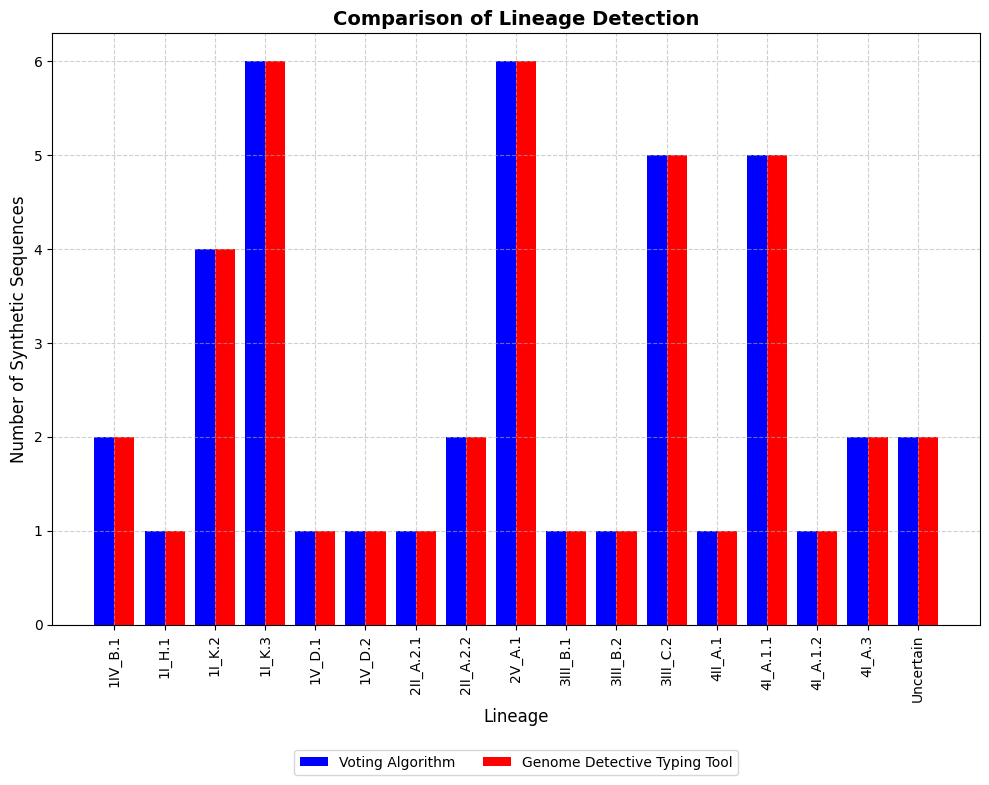

In [38]:
create_comparison_lineage(df_confrontation_vote_1)

In [39]:
#@title Method 2: VOTING MECHANISM 2
# START
start_time = time.time()  # Record the start time
### I. Models and Lineages
# Model 1:  LightGBM
# 5-mers
lgbm_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/LGBM_model.joblib')
lgbm_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/LGBM_label_encoder.joblib')
# 32-FCGR
lgbm_fcgr_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_model.joblib')
lgbm_fcgr_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/LGBM_FCGR_label_encoder.joblib')


# Model 2 : XGBoost
# 5-mers
xgb_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/XGB_model.joblib')
xgb_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/XGB_label_encoder.joblib')
# 32-FCGR
xgb_fcgr_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_model.joblib')
xgb_fcgr_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/XGB_FCGR_label_encoder.joblib')

# Model 3: Random Forest
# 5-mers
rf_kmers_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/RF_model.joblib')
rf_kmers_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/5_MERS/RF_label_encoder.joblib')
#encoded_classes = lgbm_kmers_label_encoder.classes_
# RF-32-FCGR ML
rf_fcgr_model = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/RF_FCGR_model.joblib')
rf_fcgr_label_encoder = joblib.load('/content/content/VM_4_COLAB_DATA/ML_SAVED_MODELS/32_FCGR/RF_FCGR_label_encoder.joblib')

# Model 4: 1D CNN
cnn_one_dim_model = load_model('/content/content/Models/finCNN_self_Attention_Dengue.keras')
# Load the class labels from the JSON file
with open('/content/content/FINAL_DATASET/MODELS/1Dlineages.json', 'r') as json_file:
    lineages_one_d_loaded = json.load(json_file)
cnn_one_d_lineages = np.array(lineages_one_d_loaded)

# Model 5: 2D CNN
cnn_two_dim_model = load_model('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2DCNN_FCGR_32_Dengue.keras')
# Load the class labels from the JSON file
with open('/content/content/FINAL_DATASET/MODELS/2DCNN_FCGR/2D_32_lineages.json', 'r') as json_file:
    lineages_two_d_loaded = json.load(json_file)
cnn_two_d_lineages = np.array(lineages_two_d_loaded)
### II. DATA
X_kmers, X_ml_fcgr, X_dl_fcgr, X_cnn,y = preprocessing_for_pretrained_models(generated_df,df)
### CLASSIFICATION
df3 = voting_mechanism_two(X_kmers, X_dl_fcgr,THRESHOLD=0.55)
#END
end_time = time.time()  # Record the end time
duration = end_time - start_time  # Calculate the duration
print(f'Total duration to classify all valid synthetic samples = {duration:.2f} seconds.')
df3.head()

Total duration to classify all valid synthetic samples = 7.32 seconds.


,ID,Mean Probability,Voted_Lineage
0,VAE_SAMPLE_1,0.989640,1IV_B.1
1,VAE_SAMPLE_2,0.999658,1IV_B.1
2,VAE_SAMPLE_6,0.998469,4I_A.1.1
3,VAE_SAMPLE_9,0.999728,1I_K.3
4,VAE_SAMPLE_12,0.999976,2V_A.1


In [40]:
#@title Lineage Detection Comparison
# Merge the Voting Results and the Genome Detective
df_confrontation_vote_2 = pd.merge(df3,df1,on='ID', how='inner')
df_confrontation_vote_2

,ID,Mean Probability,Voted_Lineage,Genome_Detective_Typing_Tool_Lineage
0,VAE_SAMPLE_1,0.989640,1IV_B.1,1IV_B.1
1,VAE_SAMPLE_2,0.999658,1IV_B.1,1IV_B.1
2,VAE_SAMPLE_6,0.998469,4I_A.1.1,4I_A.1.1
3,VAE_SAMPLE_9,0.999728,1I_K.3,1I_K.3
4,VAE_SAMPLE_12,0.999976,2V_A.1,2V_A.1
5,VAE_SAMPLE_15,0.899570,1I_K.3,1I_K.3
6,VAE_SAMPLE_16,0.989711,2II_A.2.1,2II_A.2.1
7,VAE_SAMPLE_23,0.999886,2II_A.2.2,2II_A.2.2
8,VAE_SAMPLE_30,0.997789,1I_H.1,1I_H.1
9,VAE_SAMPLE_32,0.999936,1I_K.2,1I_K.2


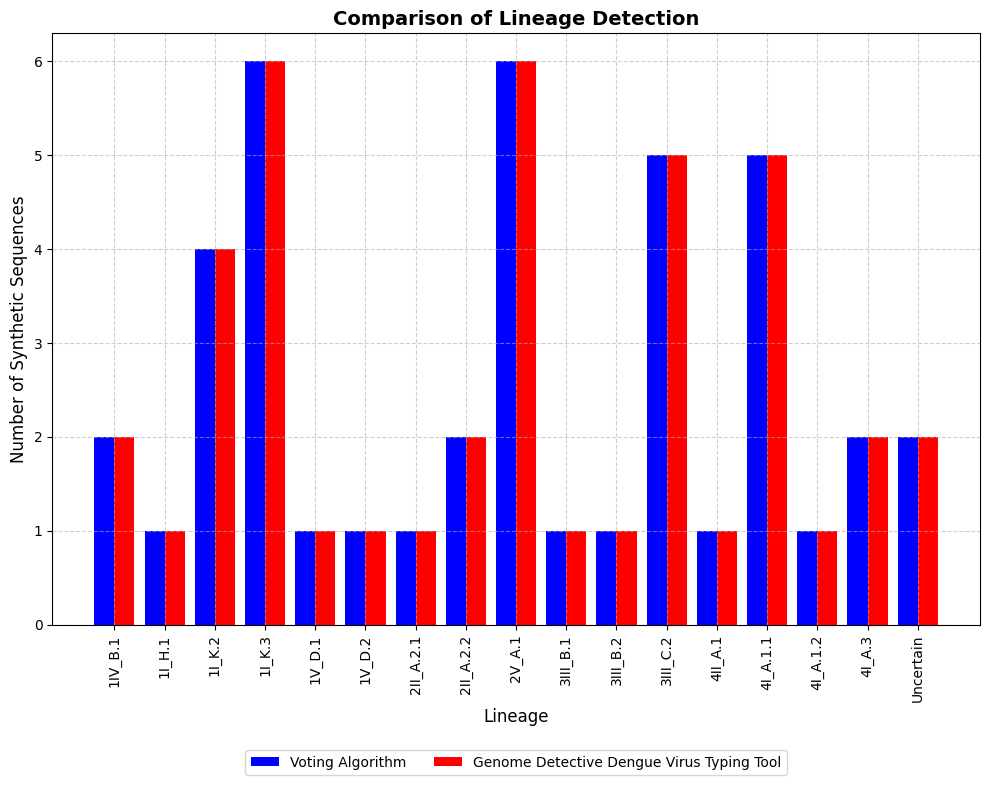

In [46]:
create_comparison_lineage(df_confrontation_vote_2)

# `3.4. Experimentations`

In [53]:
#@title 3.4.1. Timing comparison : Voting Mechanism 2 and Genome Detective Typing Tool
days = np.arange(1, 11) # Days/experiments 1 to 10
vote_times = [4.43, 8.5, 5, 5.1, 5.2, 7.5, 6, 4.2, 4.9, 7]  # Voting Algorithm times (seconds)
detective_times = [41, 44, 42, 44, 40, 41, 45, 42, 40, 43]  # Dengue Detective Typing Tool times (minutes)

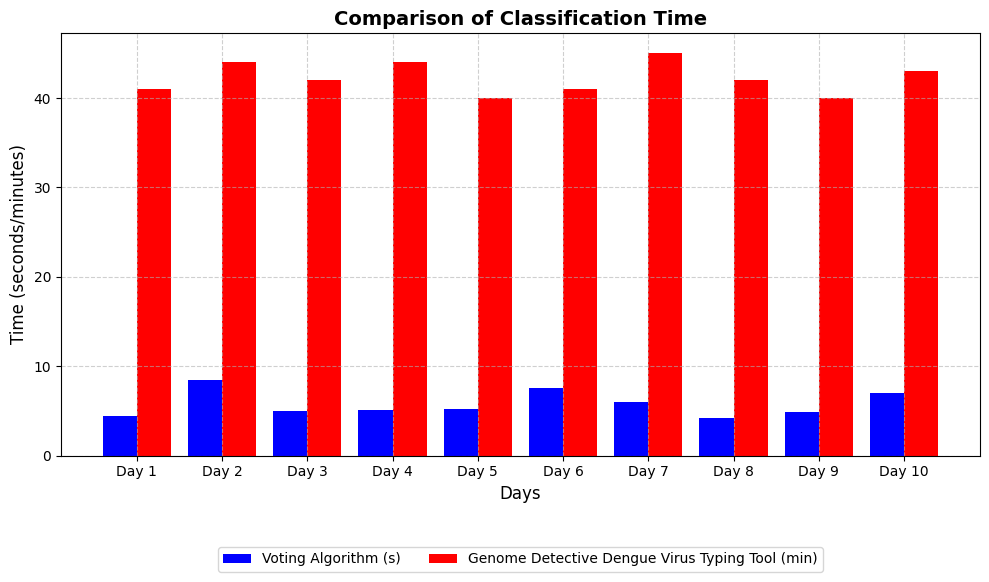

In [54]:
#@title 3.4.2. Plot
create_comparison_timing(days, vote_times, detective_times)